# Phase 9 - Explainability and Business Impact

This notebook formalises the explainability of the selected forecasting approach and translates the final predictions into business-facing indicators.

The selected model is intrinsically interpretable: each open-store prediction is based on the recent 365-day historical mean for the same `Store`, `DayOfWeek`, and `Promo` combination, with a documented fallback hierarchy. Closed stores receive a prediction of zero.

The analysis below is descriptive rather than causal. It explains how the forecast is structured and which operational segments account for the predicted sales.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "reports").exists() and (candidate / "models").exists():
            return candidate
    raise FileNotFoundError("Project root not found.")

ROOT = find_project_root()
TABLES = ROOT / "reports" / "tables"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

forecast = pd.read_csv(TABLES / "final_test_forecast.csv", low_memory=False)
store_forecast = pd.read_csv(TABLES / "final_store_forecast.csv")
promo = pd.read_csv(TABLES / "final_promo_forecast.csv")
weekday = pd.read_csv(TABLES / "final_weekday_forecast.csv")
metadata = json.loads((ROOT / "models" / "final_model_metadata.json").read_text(encoding="utf-8"))

forecast["Date"] = pd.to_datetime(forecast["Date"])
print(f"Repository root: {ROOT}")
print(f"Forecast rows: {len(forecast):,}")
print(f"Forecast stores: {forecast['Store'].nunique():,}")
print(f"Forecast dates: {forecast['Date'].nunique():,}")

Repository root: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting
Forecast rows: 41,088
Forecast stores: 856
Forecast dates: 48


## 1. Intrinsic model explainability

The production model does not rely on an opaque black-box prediction. Its logic is:

1. Restrict the history to the 365 days preceding the forecast.
2. Calculate the mean sales for each `Store + DayOfWeek + Promo` combination.
3. If the exact combination is unavailable, fall back to:
   - `Store + DayOfWeek`;
   - `Store`;
   - global open-store mean.
4. Set predicted sales to zero when the store is closed.
5. Preserve the imputation flag for the 11 missing `Open` values from Store 622.

This makes each prediction traceable to a business-relevant historical peer group.

In [2]:
pd.Series({
    "Model": metadata["model_name"],
    "Model type": metadata["model_type"],
    "History window": f"{metadata['history_window_days']} days",
    "Segmentation": " + ".join(metadata["segmentation"]),
    "Fallback hierarchy": " -> ".join(metadata["fallback_hierarchy"]),
    "Closed-store rule": metadata["closed_store_rule"],
    "Missing-Open rule": metadata["missing_open_rule"],
})

Model                            Recent 365-day Store + weekday + Promo
Model type                                Rule-based historical average
History window                                                 365 days
Segmentation                                  Store + DayOfWeek + Promo
Fallback hierarchy    Store + DayOfWeek -> Store -> Global open-stor...
Closed-store rule                PredictedSales = 0 when OpenFilled = 0
Missing-Open rule     The 11 missing Open values for Store 622 are f...
dtype: object

## 2. Business KPI translation

In [3]:
open_mask = forecast["OpenFilled"].eq(1)
promo_row = promo.loc[promo["Promo"].eq(1)].iloc[0]
nonpromo_row = promo.loc[promo["Promo"].eq(0)].iloc[0]

kpis = pd.Series({
    "Forecast sales": forecast["PredictedSales"].sum(),
    "Forecast rows": len(forecast),
    "Forecast stores": forecast["Store"].nunique(),
    "Forecast dates": forecast["Date"].nunique(),
    "Open store days": int(open_mask.sum()),
    "Closed store days": int((~open_mask).sum()),
    "Promo open store days": int((open_mask & forecast["Promo"].eq(1)).sum()),
    "Mean sales per open store day": forecast.loc[open_mask, "PredictedSales"].mean(),
    "Promo uplift": promo_row["mean_sales"] / nonpromo_row["mean_sales"] - 1,
    "Promo share of sales": promo_row["forecast_sales"] / promo["forecast_sales"].sum(),
})
kpis

Forecast sales                   2.470341e+08
Forecast rows                    4.108800e+04
Forecast stores                  8.560000e+02
Forecast dates                   4.800000e+01
Open store days                  3.510400e+04
Closed store days                5.984000e+03
Promo open store days            1.625200e+04
Mean sales per open store day    7.037207e+03
Promo uplift                     3.496676e-01
Promo share of sales             5.377916e-01
dtype: float64

## 3. Promotion effect

Promotion is the strongest explicitly modelled operating condition. The comparison below shows the average forecast per open store day with and without promotion. It should be interpreted as a forecast segmentation, not as a causal experiment.

In [4]:
promo_effect = pd.DataFrame({
    "status": ["Non-promo", "Promo"],
    "mean_sales": [nonpromo_row["mean_sales"], promo_row["mean_sales"]],
    "open_store_days": [nonpromo_row["open_store_days"], promo_row["open_store_days"]],
    "forecast_sales": [nonpromo_row["forecast_sales"], promo_row["forecast_sales"]],
})
promo_effect

,status,mean_sales,open_store_days,forecast_sales
0,Non-promo,6056.717630,18852.0,1.141812e+08
1,Promo,8174.555542,16252.0,1.328529e+08


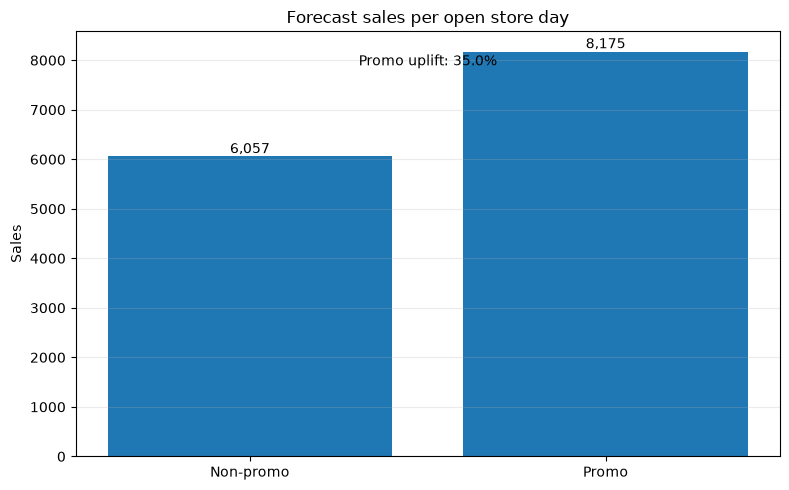

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(promo_effect["status"], promo_effect["mean_sales"])
ax.set_title("Forecast sales per open store day")
ax.set_ylabel("Sales")
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, promo_effect["mean_sales"]):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:,.0f}", ha="center", va="bottom")
ax.text(0.5, 0.92, f"Promo uplift: {kpis['Promo uplift']:.1%}", transform=ax.transAxes, ha="center")
fig.tight_layout()
fig.savefig(FIGURES / "phase9_promo_effect.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Weekday profile

In [6]:
weekday_names = {1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday", 5:"Friday", 6:"Saturday", 7:"Sunday"}
weekday_profile = weekday.copy()
weekday_profile["weekday"] = weekday_profile["DayOfWeek"].map(weekday_names)
weekday_profile[["weekday", "forecast_sales", "open_store_days", "promo_store_days", "mean_sales_per_open_store"]]

,weekday,forecast_sales,open_store_days,promo_store_days,mean_sales_per_open_store
0,Monday,4.877612e+07,5988,3421,8145.644355
1,Tuesday,4.323699e+07,5988,3421,7220.605439
2,Wednesday,4.036870e+07,5988,3421,6741.599883
3,Thursday,4.063370e+07,5989,3421,6784.722074
4,Friday,3.620068e+07,5135,2568,7049.790898
5,Saturday,3.637239e+07,5827,0,6242.043652
6,Sunday,1.445548e+06,189,0,7648.404358


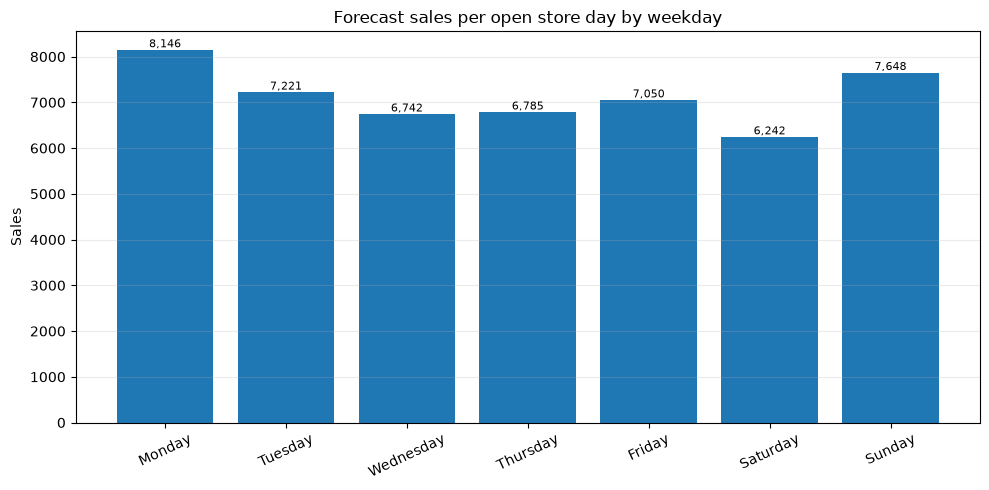

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(weekday_profile["weekday"], weekday_profile["mean_sales_per_open_store"])
ax.set_title("Forecast sales per open store day by weekday")
ax.set_ylabel("Sales")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=25)
for bar, value in zip(bars, weekday_profile["mean_sales_per_open_store"]):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase9_weekday_profile.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Store concentration and planning relevance

In [8]:
concentration = []
total_sales = store_forecast["forecast_sales"].sum()
for n in [1, 10, 25, 50, 100]:
    sales = store_forecast.nlargest(n, "forecast_sales")["forecast_sales"].sum()
    concentration.append({"top_n_stores": n, "forecast_sales": sales, "share_of_total": sales / total_sales})
concentration = pd.DataFrame(concentration)
concentration

,top_n_stores,forecast_sales,share_of_total
0,1,9.979854e+05,0.004040
1,10,7.804588e+06,0.031593
2,25,1.603978e+07,0.064929
3,50,2.754608e+07,0.111507
4,100,4.804493e+07,0.194487


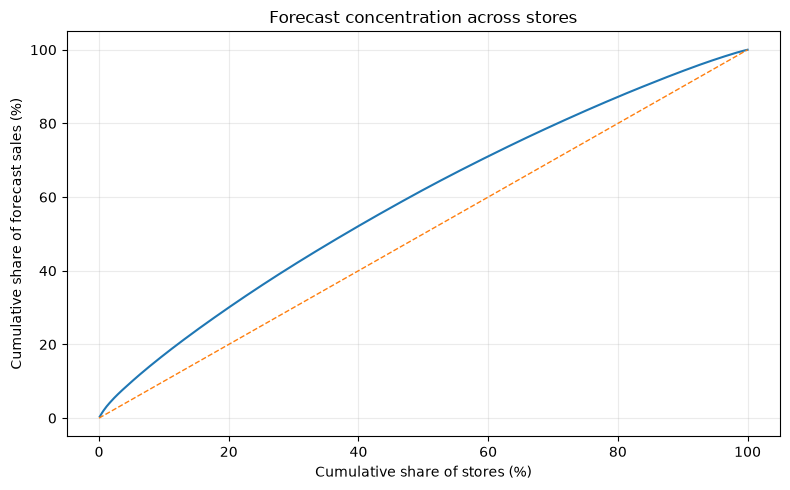

In [9]:
ordered = store_forecast.sort_values("forecast_sales", ascending=False).reset_index(drop=True)
ordered["cumulative_share"] = ordered["forecast_sales"].cumsum() / ordered["forecast_sales"].sum()
ordered["store_share"] = (ordered.index + 1) / len(ordered)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ordered["store_share"] * 100, ordered["cumulative_share"] * 100)
ax.plot([0, 100], [0, 100], linestyle="--", linewidth=1)
ax.set_title("Forecast concentration across stores")
ax.set_xlabel("Cumulative share of stores (%)")
ax.set_ylabel("Cumulative share of forecast sales (%)")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "phase9_store_concentration.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Interpretation and limitations

- The selected model is fully traceable to recent historical averages and operational segments.
- Promotion and weekday effects are directly visible in both the model structure and forecast outputs.
- Store identity captures stable local demand patterns, but it does not explain the underlying socioeconomic causes.
- The observed promotion uplift is descriptive and should not be interpreted as a causal return on promotion.
- The model is intentionally conservative: a residual boosting model achieved a slightly lower mean RMSPE, but its performance varied more across time folds.
- Future work could introduce price, local events, weather and external economic variables, followed by SHAP or permutation importance for a more complex challenger model.

## 7. Final Phase 9 controls

The Phase 9 values should reconcile with the final metadata and the Power BI dashboard:

- Forecast sales: 247,034,117.42
- Forecast rows: 41,088
- Forecast stores: 856
- Forecast dates: 48
- Open store days: 35,104
- Closed store days: 5,984
- Promo open store days: 16,252
- Mean RMSPE: 0.1445
- RMSPE standard deviation: 0.0088
- Kaggle private RMSPE: 0.14556